# Supplementary McFaline delta-average transferability

Reproduces the McFaline delta-average transferability diagnostic plot.


In [1]:
# Set to True to write image files to figures/supplement/output/.
SAVE_FIGURES = False

## Transferability diagnostics


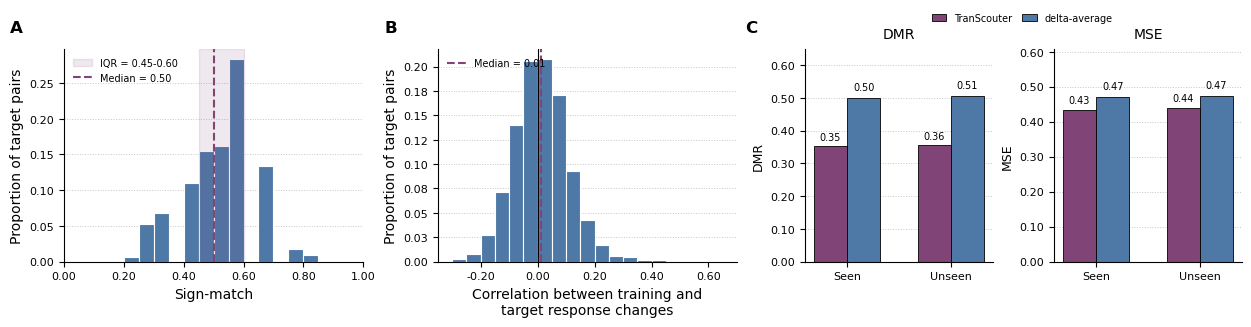

In [2]:
import os
import pickle
from pathlib import Path


ROOT = Path.cwd().resolve()
while not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()) and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()):
    raise RuntimeError("Run this notebook from inside the TranScouter repository")
os.chdir(ROOT)
OUT_DIR = ROOT / "figures" / "supplement" / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FormatStrFormatter


TRANSFER_CSV = ROOT / "results" / "baselines" / "delta_average" / "diagnosis_mcfaline_transferability.csv"
PLOT_DATA = ROOT / "results" / "baselines" / "delta_average" / "delta_avg_compare_plot_data.pkl"
OUT_FIG = OUT_DIR / "mcfaline_transferability_diagnostics.png"

SCENARIO_LABELS = {
    "McFaline Seen Perturbation": "Seen",
    "McFaline Unseen Perturbation": "Unseen",
}
METHODS = ["TranScouter", "DeltaAverage"]
METHOD_LABELS = {"TranScouter": "TranScouter", "DeltaAverage": "delta-average"}
COLORS = {"TranScouter": "#814476", "DeltaAverage": "#4E79A7"}


def fmt2(value):
    return f"{float(value) + 1e-9:.2f}"


def load_overall():
    with open(PLOT_DATA, "rb") as f:
        data = pickle.load(f)
    overall = data["overall_summary"]
    return overall[
        overall["scenario"].isin(SCENARIO_LABELS) & overall["method"].isin(METHODS)
    ].copy()


def draw_metric_bars(ax, overall, metric, ylabel):
    group_x = np.arange(len(SCENARIO_LABELS))
    width = 0.32
    ymax = 0
    for method_i, method in enumerate(METHODS):
        values = []
        for scenario in SCENARIO_LABELS:
            value = overall[
                (overall["scenario"] == scenario) & (overall["method"] == method)
            ][metric].iloc[0]
            values.append(float(value))
        xpos = group_x + (method_i - 0.5) * width
        bars = ax.bar(
            xpos,
            values,
            width=width,
            label=METHOD_LABELS[method],
            color=COLORS[method],
            edgecolor="black",
            linewidth=0.6,
        )
        ymax = max(ymax, max(values))
        offset = max(ymax * 0.035, 0.008)
        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + offset,
                fmt2(value),
                ha="center",
                va="bottom",
                fontsize=7,
            )

    ax.set_xticks(group_x)
    ax.set_xticklabels(list(SCENARIO_LABELS.values()), fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0, ymax * 1.28)
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.yaxis.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.tick_params(axis="y", labelsize=8)
    return ax.get_legend_handles_labels()


def add_centered_method_legend(fig, ax_left, ax_right, handles, labels):
    fig.canvas.draw()
    left_pos = ax_left.get_position()
    right_pos = ax_right.get_position()
    center_x = (left_pos.x0 + right_pos.x1) / 2
    top_y = max(left_pos.y1, right_pos.y1) + 0.035
    fig.legend(
        handles,
        labels,
        frameon=False,
        fontsize=7,
        loc="lower center",
        bbox_to_anchor=(center_x, top_y),
        bbox_transform=fig.transFigure,
        ncol=2,
        columnspacing=1.0,
        handlelength=1.5,
    )


def main():
    transfer = pd.read_csv(TRANSFER_CSV)
    overall = load_overall()

    sign_match = transfer["avg_delta_sign_match"]
    pair_corr = transfer["mean_pair_corr"]
    sm_median = sign_match.median()
    sm_q25 = sign_match.quantile(0.25)
    sm_q75 = sign_match.quantile(0.75)
    corr_median = pair_corr.median()

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(12.4, 3.05),
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1.18, 1.18, 0.74, 0.74]},
    )
    ax_a, ax_b, ax_c1, ax_c2 = axes

    bins = np.linspace(0, 1, 21)
    weights = np.ones(len(sign_match)) / len(sign_match)
    ax_a.hist(
        sign_match,
        bins=bins,
        weights=weights,
        color="#4E79A7",
        edgecolor="white",
        linewidth=0.8,
    )
    ax_a.axvspan(sm_q25, sm_q75, color="#814476", alpha=0.12, label=f"IQR = {fmt2(sm_q25)}-{fmt2(sm_q75)}")
    ax_a.axvline(sm_median, color="#814476", linestyle="--", linewidth=1.5, label=f"Median = {fmt2(sm_median)}")
    ax_a.set_xlabel("Sign-match", fontsize=10)
    ax_a.set_ylabel("Proportion of target pairs", fontsize=10)
    ax_a.set_xlim(0, 1)
    ax_a.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax_a.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax_a.yaxis.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)
    ax_a.set_axisbelow(True)
    ax_a.spines["right"].set_visible(False)
    ax_a.spines["top"].set_visible(False)
    ax_a.tick_params(labelsize=8)
    ax_a.legend(frameon=False, fontsize=7, loc="upper left")

    pair_corr = pair_corr.dropna()
    corr_weights = np.ones(len(pair_corr)) / len(pair_corr)
    corr_bins = np.linspace(-0.35, 0.70, 22)
    ax_b.hist(
        pair_corr,
        bins=corr_bins,
        weights=corr_weights,
        color="#4E79A7",
        edgecolor="white",
        linewidth=0.8,
    )
    ax_b.axvline(0, color="black", linewidth=0.8)
    ax_b.axvline(corr_median, color="#814476", linestyle="--", linewidth=1.5, label=f"Median = {fmt2(corr_median)}")
    ax_b.set_xlabel("Correlation between training and\ntarget response changes", fontsize=10)
    ax_b.set_ylabel("Proportion of target pairs", fontsize=10)
    ax_b.set_xlim(-0.35, 0.70)
    ax_b.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax_b.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax_b.yaxis.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)
    ax_b.set_axisbelow(True)
    ax_b.spines["right"].set_visible(False)
    ax_b.spines["top"].set_visible(False)
    ax_b.tick_params(labelsize=8)
    ax_b.legend(frameon=False, fontsize=7, loc="upper left")

    handles, labels = draw_metric_bars(ax_c1, overall, "DMR_degs", "DMR")
    draw_metric_bars(ax_c2, overall, "MSE_degs", "MSE")
    ax_c1.set_title("DMR", fontsize=10, pad=8)
    ax_c2.set_title("MSE", fontsize=10, pad=8)
    add_centered_method_legend(fig, ax_c1, ax_c2, handles, labels)

    ax_a.text(-0.18, 1.08, "A", transform=ax_a.transAxes, fontsize=12, fontweight="bold")
    ax_b.text(-0.18, 1.08, "B", transform=ax_b.transAxes, fontsize=12, fontweight="bold")
    ax_c1.text(-0.32, 1.08, "C", transform=ax_c1.transAxes, fontsize=12, fontweight="bold")

    if globals().get("SAVE_FIGURES", False):
        fig.savefig(OUT_FIG, dpi=300, bbox_inches="tight")
        print(f"Saved: {OUT_FIG}")
    plt.show()
    plt.close(fig)


if __name__ == "__main__":
    main()
